# Wishart Distribution

`Wishart(df, scale)` is a distribution over symmetric, positive-definite matrices -- the matrix generalization of the chi-square distribution. If you draw `df` independent mean-zero `MultivariateNormal` vectors with covariance `scale` and sum their outer products, the resulting `p x p` matrix is Wishart-distributed.

In [2]:
from symbulate import *

## Draw a value

Each draw is a `p x p` symmetric positive-definite matrix, shown as a vector of its rows.

In [3]:
Wishart(df=5, scale=[[1, 0], [0, 1]]).draw()

((4.426187842165263, -0.23105290606253664), (-0.23105290606253664, 6.200564349249906))

## Simulate

Every simulated value is a 2x2 matrix.

In [4]:
Wishart(df=5, scale=[[1, 0], [0, 1]]).sim(1000)

0,"((5.066403288729594, 2.963213932173597), (2.963213932173597, 8.425600890429143))"
1,"((3.228531394650689, 0.9364104635271249), (0.9364104635271249, 1.277401515251264))"
2,"((2.54551485692922, 1.295364119994146), (1.295364119994146, 1.1317890318849755))"
3,"((4.914193553979577, -0.8315571374847415), (-0.8315571374847415, 4.8150550492555215))"
4,"((12.623556070131611, -2.5801625441926515), (-2.5801625441926515, 1.883057080907701))"
5,"((4.379004599442951, 0.6403106890619494), (0.6403106890619494, 1.454435942226821))"
6,"((3.1756730422098043, 1.5491299193121308), (1.5491299193121308, 2.863437470274976))"
7,"((2.7768005014007167, 0.25784856522824096), (0.25784856522824096, 3.1836568255209743))"
8,"((9.782724184354333, 0.6837769802553924), (0.6837769802553924, 2.878393184141932))"
...,...
999,"((3.3995049331010034, -3.6159387651878587), (-3.6159387651878587, 9.649726677686997))"


## Evaluate the pdf at a matrix

The density is defined over symmetric positive-definite matrices, so the point passed to `pdf` is itself a matrix.

In [5]:
Wishart(df=5, scale=[[1, 0], [0, 1]]).pdf([[1, 0], [0, 1]])

np.float64(0.004879152627026595)

## Relationship: diagonal entries are chi-square

With an identity scale matrix, each diagonal entry of a Wishart draw is a chi-square with `df` degrees of freedom.

Currently Showing: Density Plot
Alternative Plots: Histogram (Default), Rug Plot (type = "rug"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


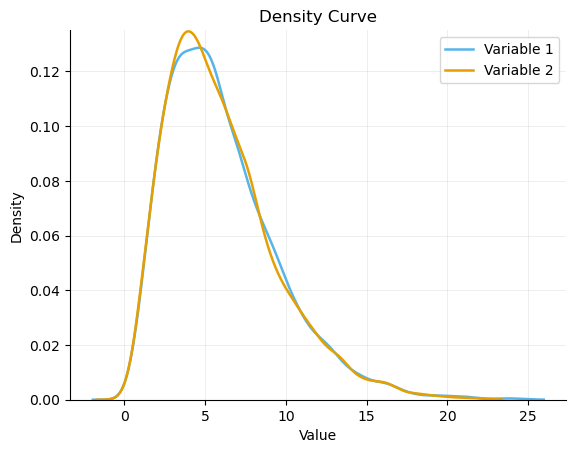

In [6]:
W = RV(Wishart(df=6, scale=[[1, 0], [0, 1]]))
W.apply(lambda m: m[0][0]).sim(10000).plot(type="density")
RV(ChiSquare(df=6)).sim(10000).plot(type="density")

## Relationship: the 1x1 Wishart is a scaled chi-square (a gamma)

In one dimension the Wishart reduces to a scaled chi-square: `Wishart(df, [[s]])` equals `s * ChiSquare(df)`, which is the same as `Gamma(shape=df/2, scale=2*s)`. Here `df=6`, `s=2`.

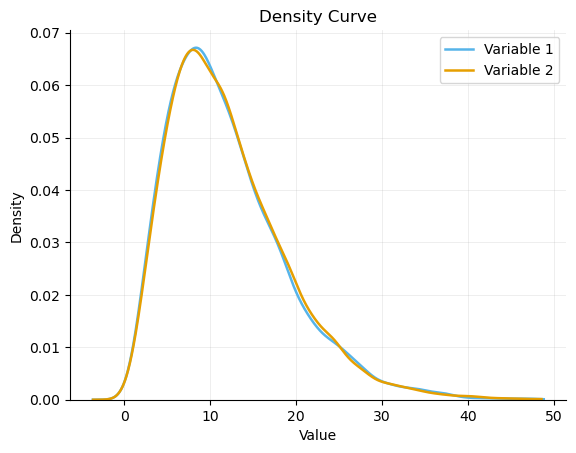

In [7]:
V = RV(Wishart(df=6, scale=[[2]]))
V.apply(lambda m: m[0][0]).sim(10000).plot(type="density")
RV(Gamma(shape=6 / 2, scale=2 * 2)).sim(10000).plot(type="density")